In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("ALL libraries loaded successfully!")

ALL libraries loaded successfully!


In [9]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\BI project\Data Folder\bank-full.csv',sep=';')
print("dataset loaded!")
print("shape:", df.shape)
print("Columns:", df.columns.tolist())      

dataset loaded!
shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [10]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [11]:
print(" MISSING VALUES ")
print(df.isnull().sum())
print("\n DATA TYPES ")
print(df.dtypes)
print("\n BASIC STATS ")
print(df.describe())


 MISSING VALUES 
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

 DATA TYPES 
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

 BASIC STATS 
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.0

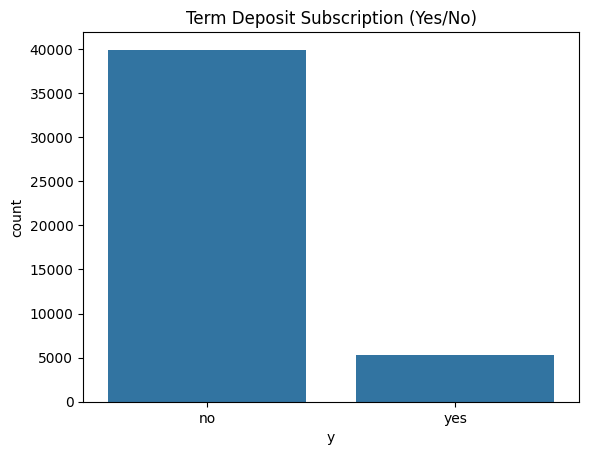

In [12]:
sns.countplot(x='y',data=df)
plt.title('Term Deposit Subscription (Yes/No)')
plt.show()

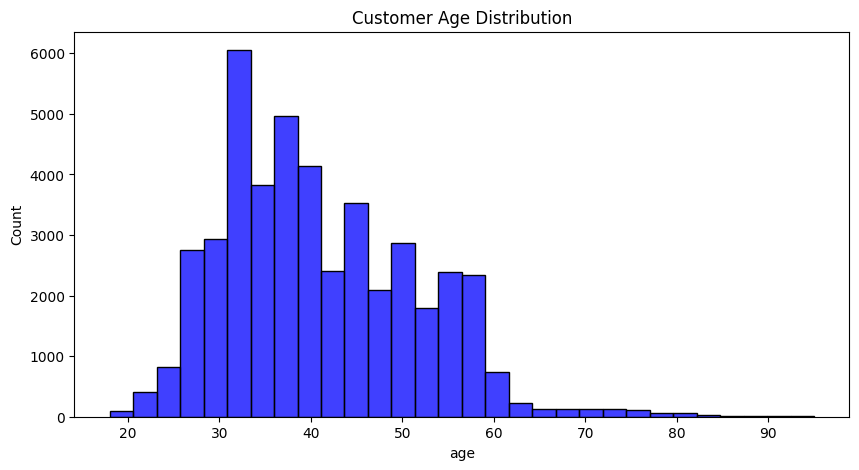

In [13]:
plt.figure (figsize=(10,5))
sns.histplot(df['age'], bins=30, color='blue')
plt.title('Customer Age Distribution')
plt.ylabel('Count')
plt.show()

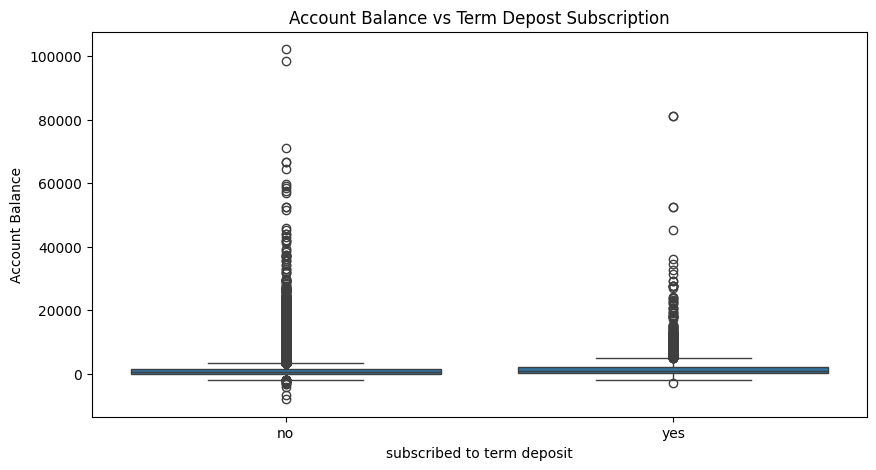

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y',y='balance', data=df)
plt.title('Account Balance vs Term Depost Subscription')
plt.xlabel('subscribed to term deposit')
plt.ylabel('Account Balance')
plt.show()

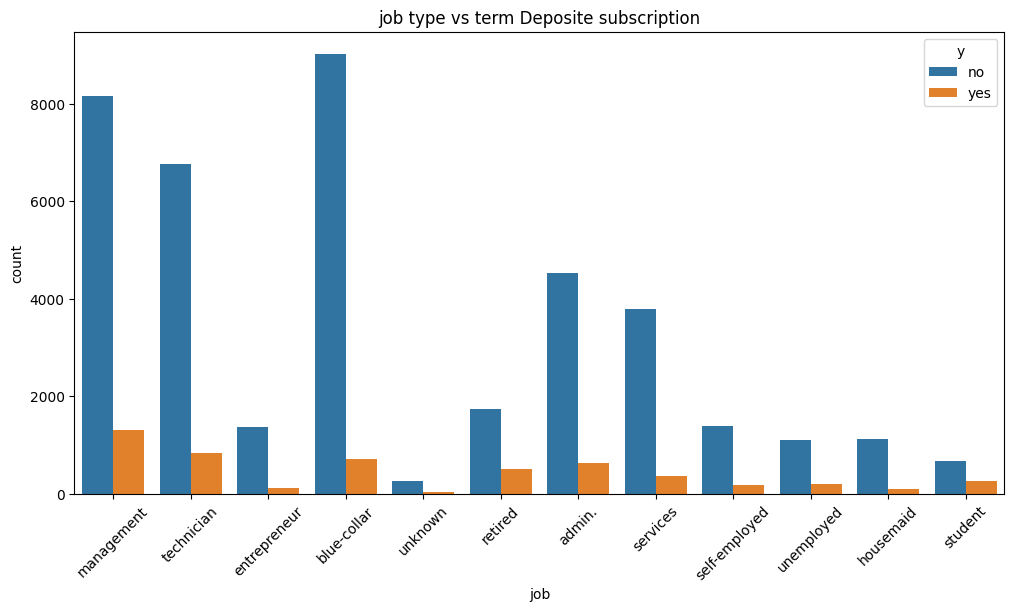

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(x='job',hue='y',data=df)
plt.title('job type vs term Deposite subscription')
plt.xticks(rotation=45)
plt.show()

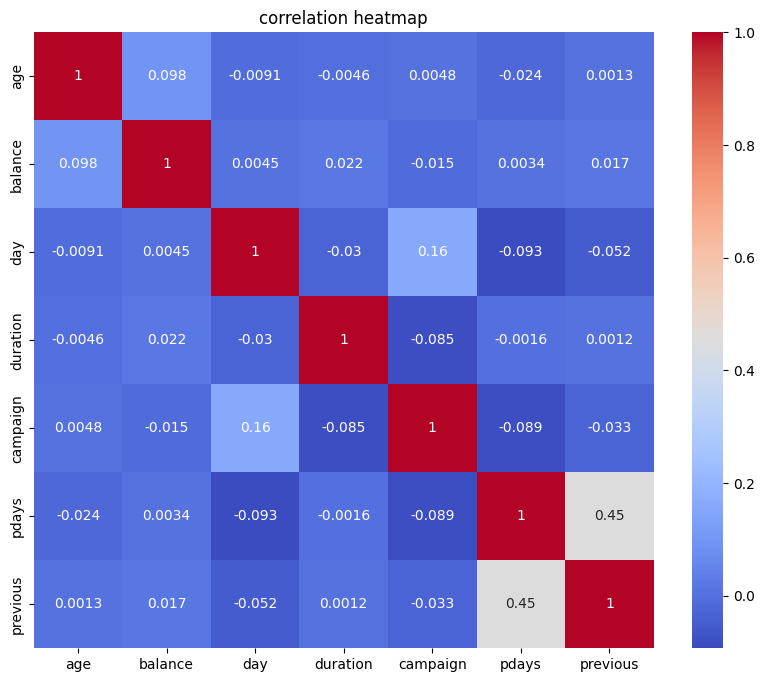

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

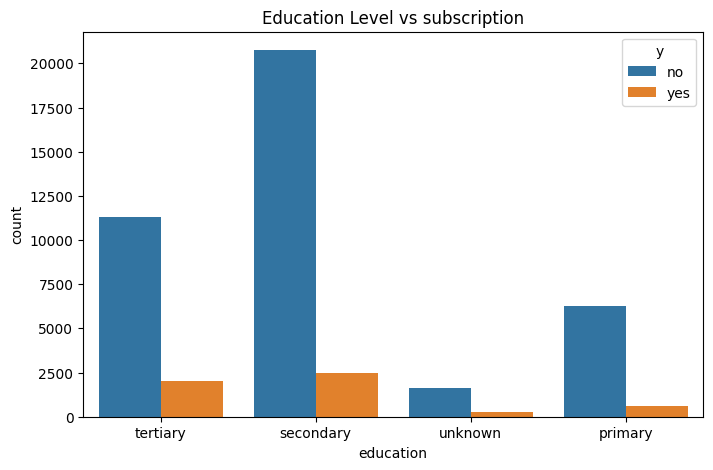

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='education',hue='y',data=df)
plt.title('Education Level vs subscription')
plt.show()


In [19]:
Q1=df['balance'].quantile(0.25)
Q3=df['balance'].quantile(0.75)
IQR=Q3-Q1
df_clean=df[df['balance']<Q3+3*IQR]
print("Original rows:",len(df))
print("Cleaned rows:", len(df_clean))
print("Removed:",len(df)-len(df_clean),"outliers")


Original rows: 45211
Cleaned rows: 42770
Removed: 2441 outliers


In [20]:
df_clean = df_clean.copy()
df_clean['y_encoded'] = (df_clean['y'] == 'yes').astype(int)
print("subscription Rate:")
print(df_clean['y_encoded'].value_counts())
print("conversion %:", round(df_clean['y_encoded'].mean()*100,2),"%")

subscription Rate:
y_encoded
0    37847
1     4923
Name: count, dtype: int64
conversion %: 11.51 %


In [22]:
df_clean.to_csv(r'c:\users\Admin\Desktop\BI project\Data Folder\bank_cleaned.csv',index=False)
print(" cleaned data saved successfully!")
print("shape:", df_clean.shape)

 cleaned data saved successfully!
shape: (42770, 18)


In [23]:
import sqlite3
import pandas as pd
#load cleaned data
df_clean = pd.read_csv(r'c:\users\Admin\Desktop\BI project\Data Folder\bank_cleaned.csv')
#create SQL database from database from your CVS
conn = sqlite3.connect('bank_marketing.db')
df_clean.to_sql('bank',conn, if_exists='replace',index=False)
print(" Database created successfully!")
print("Total records loaded  :",len(df_clean))

 Database created successfully!
Total records loaded  : 42770


In [26]:
query1="""
SELECT job,
       COUNT(*) as total_customers,
       SUM(y_encoded) as subscribed,
       ROUND(SUM(y_encoded)*100.0/COUNT(*),2) as conversion_rate
 FROM bank
 GROUP BY job
 ORDER BY conversion_rate DESC
 """
result1 = pd.read_sql_query(query1, conn)
print("== CONVERSION RATE BY JOB ===")
print(result1)


== CONVERSION RATE BY JOB ===
              job  total_customers  subscribed  conversion_rate
0         student              885         256            28.93
1         retired             2089         464            22.21
2      unemployed             1215         190            15.64
3      management             8713        1181            13.55
4          admin.             4992         601            12.04
5         unknown              266          32            12.03
6   self-employed             1467         170            11.59
7      technician             7204         777            10.79
8        services             3998         359             8.98
9       housemaid             1182         103             8.71
10   entrepreneur             1399         114             8.15
11    blue-collar             9360         676             7.22


In [27]:
query2 = """
SELECT education,
       ROUND(AVG(balance),2) as avg_balance,
       COUNT(*) as total_customers
FROM bank
GROUP BY education
ORDER BY avg_balance DESC
"""
result2 = pd.read_sql_query(query2, conn)
print("=== AVERAGE BALANCE BY EDUCATION ===")
print( result2 )
       

=== AVERAGE BALANCE BY EDUCATION ===
   education  avg_balance  total_customers
0   tertiary       958.68            12296
1    unknown       926.18             1737
2    primary       827.23             6527
3  secondary       763.23            22210


In [31]:
query3="""
SELECT month,
       COUNT(*) as total_contacts,
       sum(y_encoded) as subscribed,
       ROUND(SUM(y_encoded)*100.0/count(*),2) as conversion_rate
FROM bank
GROUP BY month
ORDER BY conversion_rate DESC
"""
result3 = pd.read_sql_query(query3, conn)
print("== BEST MONTH FOR CAMPAIGN==")
print(result3)





== BEST MONTH FOR CAMPAIGN==
   month  total_contacts  subscribed  conversion_rate
0    mar             430         224            52.09
1    dec             196          92            46.94
2    sep             534         246            46.07
3    oct             668         294            44.01
4    apr            2774         543            19.57
5    feb            2518         406            16.12
6    aug            5889         637            10.82
7    nov            3455         362            10.48
8    jun            5006         516            10.31
9    jan            1370         135             9.85
10   jul            6697         599             8.94
11   may           13233         869             6.57


In [33]:
query4="""
SELECT job, education,
       ROUND(AVG(balance),2) as avg_balance,
       COUNT(*) as total
FROM bank 
WHERE y_encoded = 1
GROUP BY job, education
ORDER BY avg_balance DESC
LIMIT 10
"""
result4 = pd.read_sql_query(query4, conn)
print(" ===  TOP 10 HIGH VALUE SUBSCRIBERS ===")
print(result4)


 ===  TOP 10 HIGH VALUE SUBSCRIBERS ===
             job  education  avg_balance  total
0  self-employed    unknown      3079.60      5
1     management    primary      2123.76     21
2     technician    unknown      1844.59     17
3      housemaid    unknown      1842.25      4
4         admin.    unknown      1804.50     16
5     management    unknown      1772.93     44
6        unknown  secondary      1753.44      9
7        retired   tertiary      1594.70     93
8      housemaid   tertiary      1578.24     21
9        retired    primary      1541.07    159


In [35]:
query5 = """
SELECT loan, housing , COUNT(*)  as  total , ROUND(SUM(y_encoded)*100.0/COUNT(*),2) as conversion_rate FROM bank GROUP BY loan , housing ORDER BY conversion_rate DESC"""
        
result5 = pd.read_sql_query(query5, conn)
print("==RISK SEGMENT ANALYSIS ===")
print(result5)


==RISK SEGMENT ANALYSIS ===
  loan housing  total  conversion_rate
0   no      no  15945            18.07
1   no     yes  19748             7.94
2  yes      no   2824             7.51
3  yes     yes   4253             6.14
